# 5. Normalisation
## 5.1. Introduction and Evaluation

Before constructing the final composite index, the retained indicators must be normalised to make them directly comparable. The indicators currently exist in different units and scales, including percentages, per-capita measures, monetary values, and growth rates. Without normalisation, variables with larger numerical ranges could dominate the aggregation process and distort the final index structure.

Following the OECD Handbook on Constructing Composite Indicators, I first assess the statistical properties of the retained indicators before selecting an appropriate normalisation procedure. In particular, I examine:

- the distribution of each indicator
- the presence of skewness
- potential outliers
- scale differences across variables

This diagnostic step helps determine whether transformations such as logarithmic scaling are necessary before applying the final normalisation method.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

imputed_data_path = "../data/worldbank_imputed_data.csv"

In [5]:
retained_features = [
        # Finance & Investment
        "credit_to_private_sector",
        "fdi_inflows",
        "market_capitalisation",

        # Technology & Innovation
        "broadband_subscriptions",
        "internet_usage_rate",
        "secure_servers_density",
        "rd_expenditure",

        # Economic Growth & Stability
        "gdp_growth",
        "inflation_rate",
        "real_interest_rate",
        "capital_formation",

        # Talent & Productivity
        "tertiary_enrollment",
        "labor_productivity",
        "high_tech_exports",
        "ict_imports"
    ]

In [6]:
if not os.path.exists(imputed_data_path):
    print(f"'{imputed_data_path}' not found.")
else:
    df_snapshot = pd.read_csv(imputed_data_path)
    
    # Summary statistics 
    diagnostics_df = pd.DataFrame({
        "Minimum": df_snapshot[retained_features].min(),
        "Maximum": df_snapshot[retained_features].max(),
        "Mean": df_snapshot[retained_features].mean(),
        "Std Dev": df_snapshot[retained_features].std(),
        "Skewness": df_snapshot[retained_features].skew()
    })

    print("==============================================================================")
    print("                          Variables Distribution Summary                      ")
    print("==============================================================================")
    print(diagnostics_df.round(4))

                          Variables Distribution Summary                      
                            Minimum       Maximum        Mean      Std Dev  \
credit_to_private_sector     3.0966  2.310378e+02     55.2254      40.1659   
fdi_inflows              -1303.1083  1.705380e+02     -2.0386      91.1638   
market_capitalisation        0.1909  1.118243e+03     56.1620      82.7424   
broadband_subscriptions      0.0000  6.097480e+01     18.5768      16.3298   
internet_usage_rate          6.6710  1.000000e+02     71.6890      25.7646   
secure_servers_density       1.2316  1.443009e+06  27460.4344  110002.8831   
rd_expenditure               0.0061  6.345900e+00      0.8856       1.0060   
gdp_growth                 -26.5575  4.381930e+01      3.0529       4.6436   
inflation_rate             -12.2970  2.549485e+02      9.2302      26.8478   
real_interest_rate         -89.4708  4.866390e+01      3.0225      12.8611   
capital_formation            1.8975  4.460670e+01     22.1722  

### 5.1.1. Distribution and Skewness Assessment

The summary shows that several indicators exhibit substantial differences in scale, dispersion, and distribution shape. While some variables appear relatively symmetric, others show strong positive or negative skewness and contain extreme outliers.

In particular:

- `market_capitalisation`
- `secure_servers_density`
- `inflation_rate`
- `ict_imports`

show very high positive skewness, indicating the presence of a small number of countries with exceptionally large values.

Similarly:

- `fdi_inflows`
- `real_interest_rate`

show strong negative skewness, suggesting the presence of extreme negative observations.

These results indicate that some indicators may disproportionately influence the composite index if left unadjusted. 

Following OECD recommendations, visual inspection of distributions and outliers will be carried out before selecting the final normalisation procedure and determining whether transformations are necessary.

In [14]:
output_figure_dir = "../artifacts/figures"
os.makedirs(output_figure_dir, exist_ok=True)

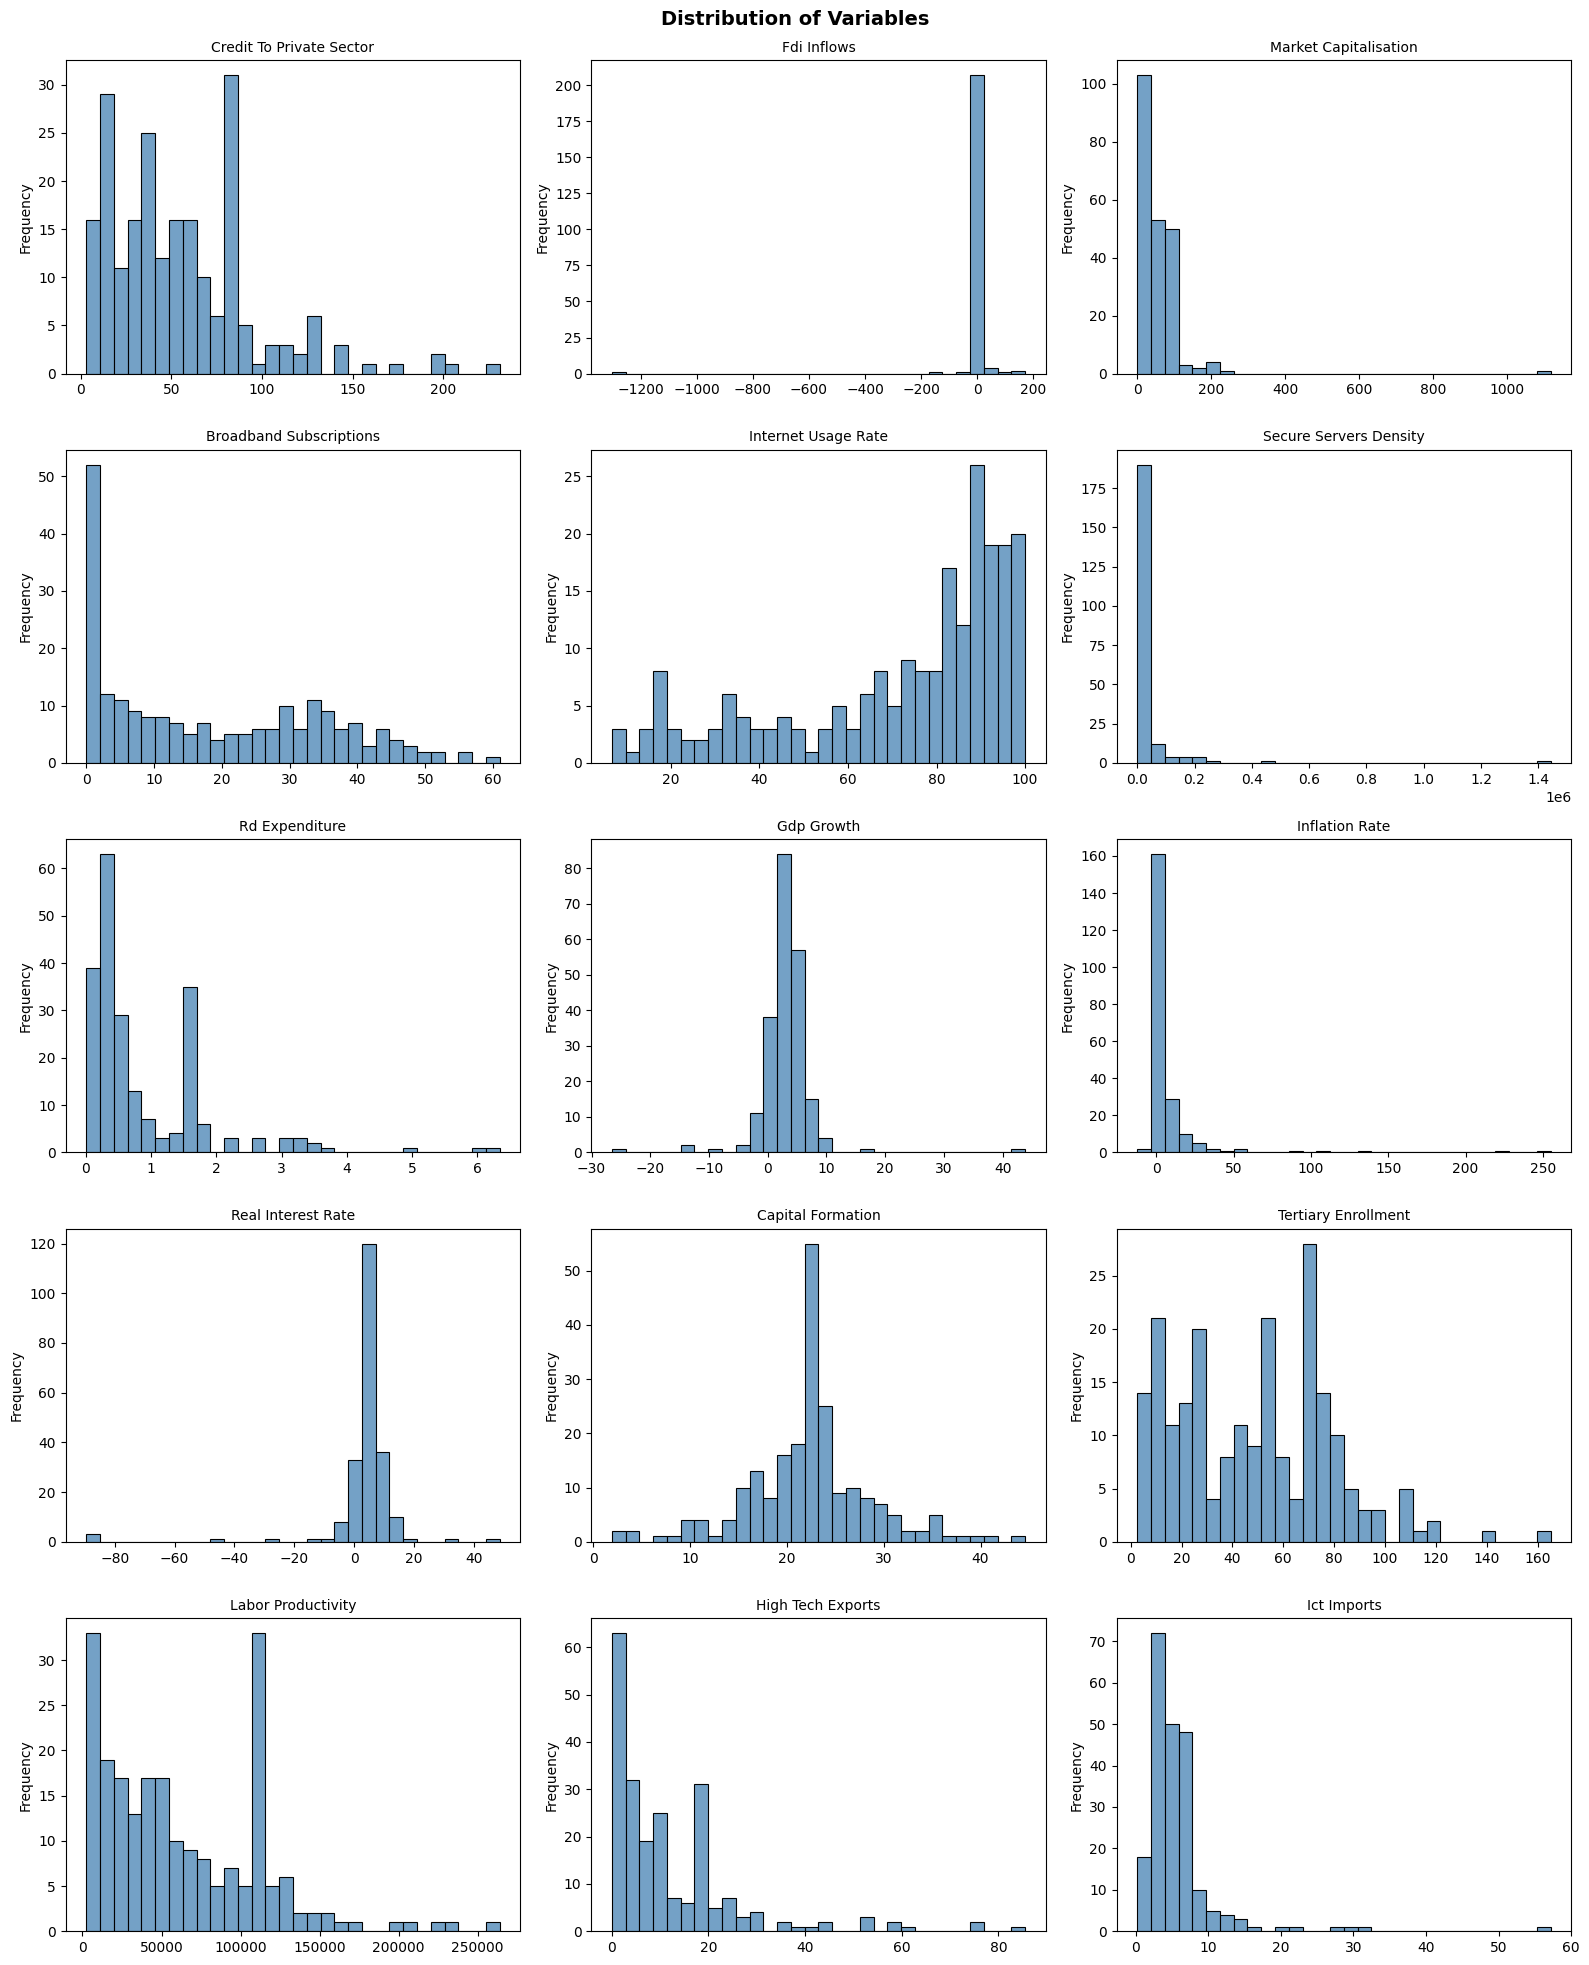

In [15]:
# Histograms for retained variables

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, column in enumerate(retained_features):
    
    sns.histplot(
        df_snapshot[column],
        bins=30,
        ax=axes[i],
        color="steelblue"
    )
    
    axes[i].set_title(column.replace("_", " ").title(), fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

# Remove empty subplot spaces
for j in range(len(retained_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Variables\n",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

save_path = os.path.join(output_figure_dir, "distribution_variables.png")
plt.savefig(save_path, dpi=300)

plt.show()
plt.close()

### 5.1.2. Outlier and Skewness Interpretation

The distribution plots show that several indicators are highly uneven across countries. This is common in international datasets because some countries perform far better or worse than others on certain economic and technology indicators.

If these variables are left unchanged, extreme values may have too much influence on the final composite index. 

To reduce this problem, logarithmic transformation will be applied to selected positive indicators before the final normalisation step. This helps reduce skewness and makes the indicators more comparable across countries.

In [19]:
# Highly skewed indicators

skewness_threshold = 2.0

highly_skewed = diagnostics_df[
    diagnostics_df["Skewness"].abs() > skewness_threshold
]

print("=================================================")
print("      Variables Showing High Skewness")
print("=================================================")
print(highly_skewed[["Skewness"]].round(4))

      Variables Showing High Skewness
                        Skewness
fdi_inflows             -13.5252
market_capitalisation    10.0585
secure_servers_density   10.4109
rd_expenditure            2.2975
inflation_rate            6.7724
real_interest_rate       -5.0407
high_tech_exports         2.3748
ict_imports               5.1318


### 5.1.3. Reducing Skewness with Power Transformation

A common way to reduce skewness is log transformation, but it only works with positive values. Since this dataset contains variables with zero or negative values, such as `fdi_inflows`, `inflation_rate`, and `real_interest_rate`, a different method is needed.

To solve this, the Yeo-Johnson Power Transformation is applied using Scikit-learn’s `PowerTransformer`. This method works with positive, zero, and negative values while reducing skewness and the effect of outliers.

This helps make the indicators more comparable before the final normalisation step.

In [23]:
from sklearn.preprocessing import PowerTransformer

# Create copy of dataset
df_transformed = df_snapshot.copy()

# Apply Yeo-Johnson transformation
power_transformer = PowerTransformer(method='yeo-johnson')

df_transformed[retained_features] = power_transformer.fit_transform(
    df_snapshot[retained_features]
)

print("Yeo-Johnson Transformation Applied")
print("All retained variables were transformed successfully")

Yeo-Johnson Transformation Applied
All retained variables were transformed successfully


### 5.1.4. Min–Max Normalisation

After reducing skewness, the indicators are normalised so all variables use the same scale. This is important because the indicators are measured in different units, such as percentages, money values, and per-capita measures.

Min–Max normalisation is used to rescale all indicators to a range between 0 and 1. This keeps the differences between countries while preventing variables with larger values from dominating the index.

The Min–Max formula is:

```math
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
```

Where:

- x = original value  
- xₘᵢₙ = minimum value of the indicator  
- xₘₐₓ = maximum value of the indicator

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max scaling
minmax_scaler = MinMaxScaler()

df_normalised = df_transformed.copy()

df_normalised[retained_features] = minmax_scaler.fit_transform(
    df_transformed[retained_features]
)

print("Min-Max Normalisation Applied")
print("All retained indicators scaled to range [0, 1]")

Min-Max Normalisation Applied
All retained indicators scaled to range [0, 1]


### 5.1.5. Reviewing Normalised Results

After applying the Yeo-Johnson transformation and Min–Max normalisation, the indicators should now be more comparable across countries and less influenced by extreme values. 
To confirm that the normalisation process was successful, I will examine the distributions of the transformed indicators and verify that all variables now fall within the expected range of 0 to 1.

This validation step helps ensure that:

- skewness has been reduced
- extreme outliers have less influence
- all indicators are measured on a common scale
- the dataset is suitable for aggregation into the final composite index

In [29]:
# Summary statistics after transformation and normalisation

post_normalisation_summary = pd.DataFrame({
    "Minimum": df_normalised[retained_features].min(),
    "Maximum": df_normalised[retained_features].max(),
    "Mean": df_normalised[retained_features].mean(),
    "Std Dev": df_normalised[retained_features].std(),
    "Skewness": df_normalised[retained_features].skew()
})

print("======================================================================")
print("              Normalised Results Distribution Summary")
print("======================================================================")
print(post_normalisation_summary.round(4))

              Normalised Results Distribution Summary
                          Minimum  Maximum    Mean  Std Dev  Skewness
credit_to_private_sector      0.0      1.0  0.4611   0.2022   -0.0398
fdi_inflows                   0.0      1.0  0.5195   0.0624    1.9015
market_capitalisation         0.0      1.0  0.4658   0.1181    0.0366
broadband_subscriptions       0.0      1.0  0.4767   0.3076   -0.2099
internet_usage_rate           0.0      1.0  0.5866   0.3087   -0.5656
secure_servers_density        0.0      1.0  0.4791   0.2193    0.0048
rd_expenditure                0.0      1.0  0.4647   0.2652    0.2507
gdp_growth                    0.0      1.0  0.3821   0.0661    2.6374
inflation_rate                0.0      1.0  0.5940   0.0743   -0.5298
real_interest_rate            0.0      1.0  0.3227   0.0816    2.6305
capital_formation             0.0      1.0  0.4558   0.1503    0.1648
tertiary_enrollment           0.0      1.0  0.4295   0.2105   -0.1373
labor_productivity            0.0   

### 5.1.6. Interpretation of Normalised Results

The results show that all indicators were successfully scaled to a common range between 0 and 1. The Yeo–Johnson transformation also reduced skewness across most variables, particularly those that originally contained extreme outliers.

Although a small amount of skewness remains in some indicators, the overall distributions are now substantially more balanced and comparable across countries. The dataset is therefore suitable for the weighting and aggregation stages of the composite index.